### Machine Learning

#### Linear Regression

### 1. Import Neccessary Libraries

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score

### 2. Import Dataset

In [5]:
pd.read_csv("Cars.csv")

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


In [6]:
cars_data = pd.read_csv("Cars.csv")

### 3.Data Understanding

#### Perform initial analysis

In [7]:
cars_data.shape

(81, 5)

In [8]:
cars_data.isna().sum()

HP     0
MPG    0
VOL    0
SP     0
WT     0
dtype: int64

In [9]:
cars_data.dtypes

HP       int64
MPG    float64
VOL      int64
SP     float64
WT     float64
dtype: object

In [10]:
cars_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   HP      81 non-null     int64  
 1   MPG     81 non-null     float64
 2   VOL     81 non-null     int64  
 3   SP      81 non-null     float64
 4   WT      81 non-null     float64
dtypes: float64(3), int64(2)
memory usage: 3.3 KB


In [11]:
cars_data.describe()

,HP,MPG,VOL,SP,WT
count,81.000000,81.000000,81.000000,81.000000,81.000000
mean,117.469136,34.422076,98.765432,121.540272,32.412577
std,57.113502,9.131445,22.301497,14.181432,7.492813
min,49.000000,12.101263,50.000000,99.564907,15.712859
25%,84.000000,27.856252,89.000000,113.829145,29.591768
50%,100.000000,35.152727,101.000000,118.208698,32.734518
75%,140.000000,39.531633,113.000000,126.404312,37.392524
max,322.000000,53.700681,160.000000,169.598513,52.997752


### Assumption Checks to perform Linear Regression

#### linearity test

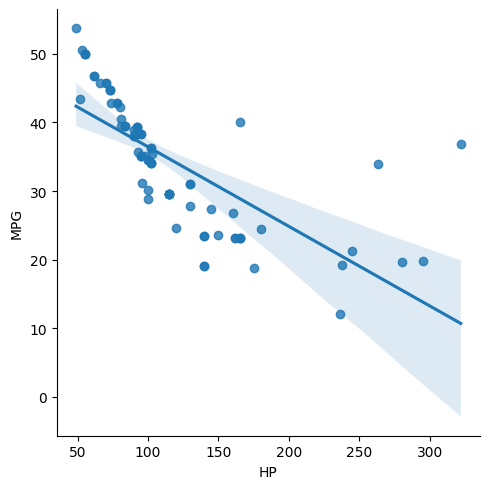

In [10]:
sns.lmplot(data=cars_data,x="HP",y="MPG")

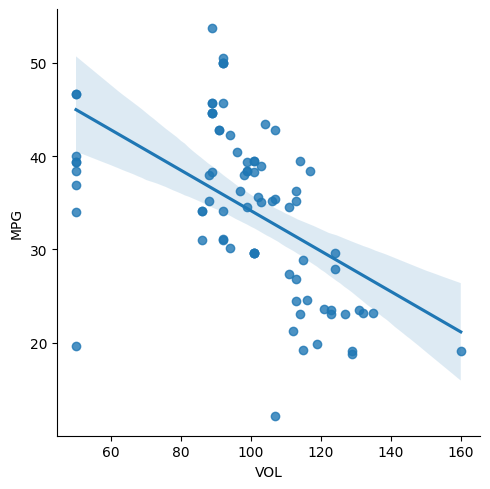

In [11]:
sns.lmplot(data=cars_data,x="VOL",y="MPG")

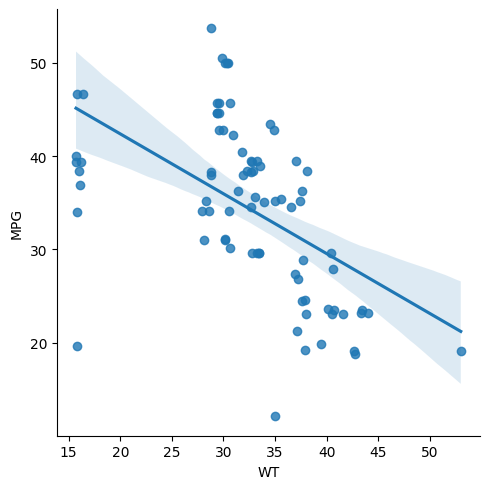

In [12]:
sns.lmplot(data=cars_data,x="WT",y="MPG")

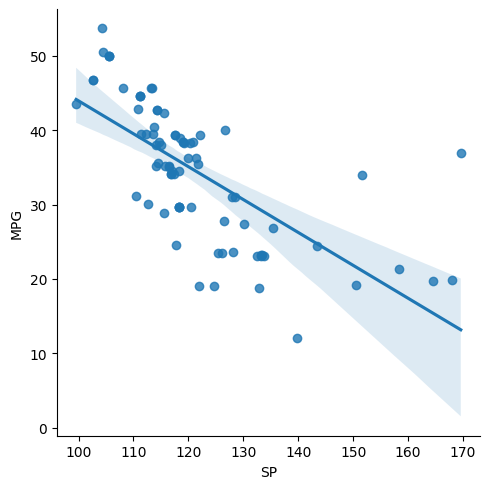

In [13]:
sns.lmplot(data=cars_data,x="SP",y="MPG")

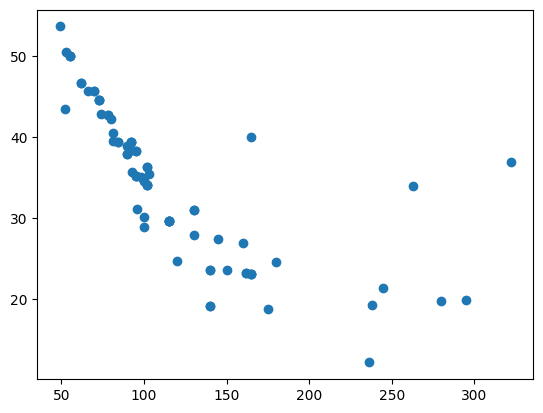

In [14]:
plt.scatter(data=cars_data,x="HP",y="MPG")

#### Test 1 linearity test failed

### Normality test

(array([15., 35.,  9.,  6.,  9.,  0.,  2.,  2.,  1.,  2.]),
 array([ 49. ,  76.3, 103.6, 130.9, 158.2, 185.5, 212.8, 240.1, 267.4,
        294.7, 322. ]),
 <BarContainer object of 10 artists>)

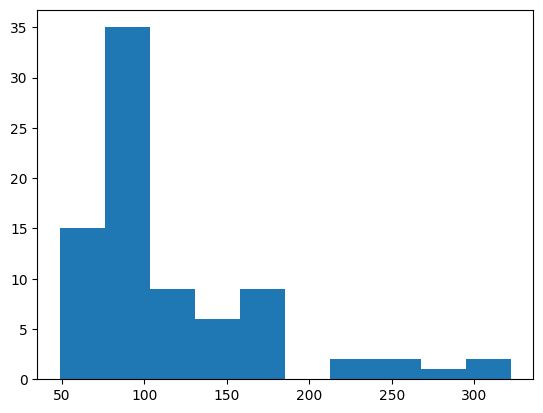

In [15]:
plt.hist(cars_data['HP'])

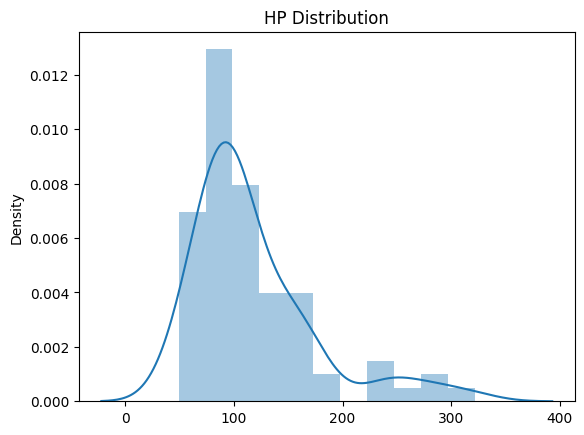

In [23]:
sns.distplot(x=cars_data['HP'])

plt.title("HP Distribution")
plt.show()

<Axes: ylabel='Density'>

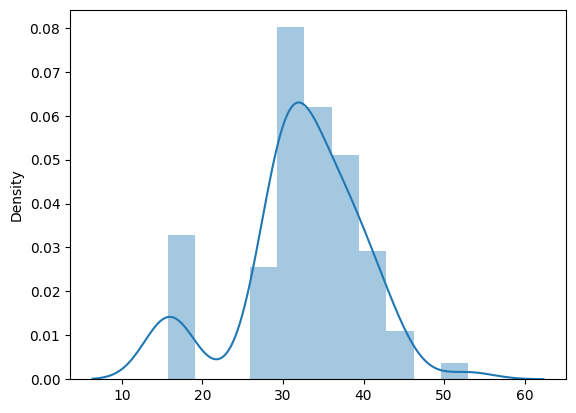

In [25]:
sns.distplot(x=cars_data['WT'])

<Axes: ylabel='Density'>

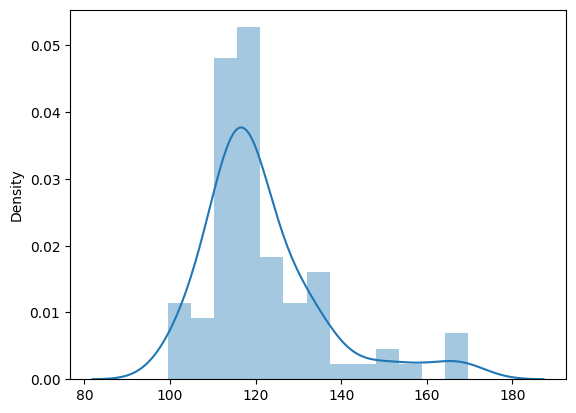

In [26]:
sns.distplot(x=cars_data['SP'])

<Axes: ylabel='Density'>

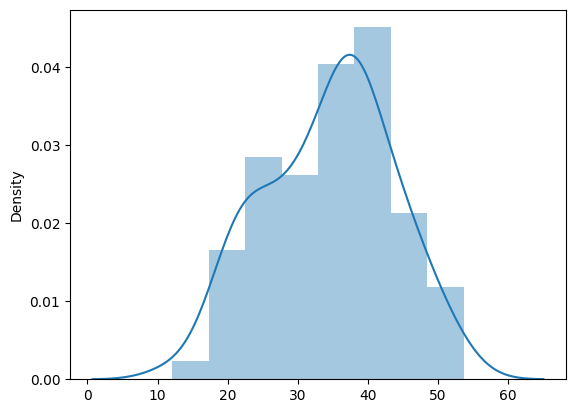

In [28]:
sns.distplot(x=cars_data['MPG'])

#### Test 2 normality test failed

### Multi-Colinearity test

In [12]:
cars_data.corr()

,HP,MPG,VOL,SP,WT
HP,1.000000,-0.725038,0.077459,0.973848,0.076513
MPG,-0.725038,1.000000,-0.529057,-0.687125,-0.526759
VOL,0.077459,-0.529057,1.000000,0.102170,0.999203
SP,0.973848,-0.687125,0.102170,1.000000,0.102439
WT,0.076513,-0.526759,0.999203,0.102439,1.000000


In [13]:
corr_matrix = cars_data.corr()

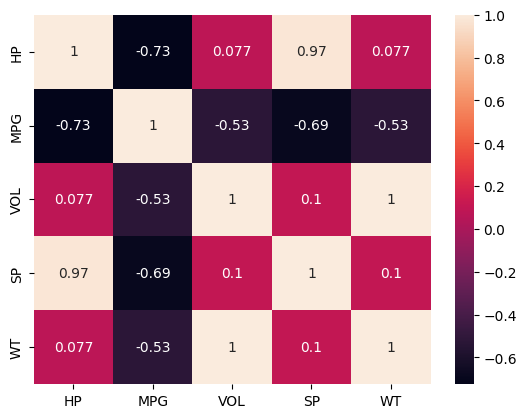

In [14]:
sns.heatmap(corr_matrix,annot=True)
plt.show()

#### Test-3 there is multi-colinearity in data

#### Test-4 Auto Regression - passed

### 4. Data Preparation

In [15]:
cars_data

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


#### there is nothing to prepare because all features in Numeric

In [16]:
X = cars_data.drop(labels=["MPG"],axis=1)

In [17]:
y = cars_data['MPG']

### 5. Model Building

In [18]:
Linear_model = LinearRegression()

### 6. Model training

In [19]:
Linear_model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
y

0     53.700681
1     50.013401
2     50.013401
3     45.696322
4     50.504232
        ...    
76    36.900000
77    19.197888
78    34.000000
79    19.833733
80    12.101263
Name: MPG, Length: 81, dtype: float64

In [21]:
Linear_model.intercept_

np.float64(30.67733585215165)

In [22]:
Linear_model.coef_

array([-0.20544372, -0.33605084,  0.39562692,  0.40057409])

### 7. Model Testing

In [23]:
y_pred = Linear_model.predict(X)

In [24]:
y

0     53.700681
1     50.013401
2     50.013401
3     45.696322
4     50.504232
        ...    
76    36.900000
77    19.197888
78    34.000000
79    19.833733
80    12.101263
Name: MPG, Length: 81, dtype: float64

In [25]:
X

,HP,VOL,SP,WT
0,49,89,104.185353,28.762059
1,55,92,105.461264,30.466833
2,55,92,105.461264,30.193597
3,70,92,113.461264,30.632114
4,53,92,104.461264,29.889149
...,...,...,...,...
76,322,50,169.598513,16.132947
77,238,115,150.576579,37.923113
78,263,50,151.598513,15.769625
79,295,119,167.944460,39.423099


In [26]:
y_pred

array([43.44193477, 42.38879289, 42.27934147, 42.53835981, 42.17264802,
       43.02061916, 42.32536062, 48.07621852, 48.28120247, 40.79122814,
       41.52153227, 47.80956747, 39.95980269, 41.52757889, 41.76632332,
       41.6181448 , 41.15094046, 47.98605515, 41.30861046, 37.87127922,
       38.57706414, 37.35199705, 37.89770285, 39.5625144 , 39.93380662,
       46.73870908, 35.48165898, 38.78152504, 38.24861192, 36.00285298,
       34.84603989, 37.21630246, 37.13919796, 34.82541399, 37.22361389,
       37.53950097, 39.27144845, 38.24219888, 38.54286458, 35.9391722 ,
       34.2129755 , 35.36313259, 37.50473376, 38.07998482, 35.79651664,
       36.2613377 , 34.21826465, 35.59393404, 36.91805291, 33.31108154,
       33.21313413, 33.3023649 , 29.19864884, 27.52358579, 28.3207133 ,
       28.56722621, 35.81583602, 33.02108459, 35.37334971, 32.29909503,
       29.87685849, 28.76093817, 25.14188416, 26.47040896, 25.97651933,
       36.35652478, 26.0975912 , 23.6416178 , 24.39887199, 20.21

### 8. Model Evaluation

In [27]:
error = y - y_pred

In [28]:
error

0     10.258747
1      7.624608
2      7.734060
3      3.157963
4      8.331584
        ...    
76    15.617904
77     1.298838
78     7.863547
79     7.517122
80    -3.458218
Name: MPG, Length: 81, dtype: float64

### Homoscedasticity Test

In [52]:
cars_data['Error'] = error

In [55]:
cars_data

,HP,MPG,VOL,SP,WT,Error
0,49,53.700681,89,104.185353,28.762059,10.258747
1,55,50.013401,92,105.461264,30.466833,7.624608
2,55,50.013401,92,105.461264,30.193597,7.734060
3,70,45.696322,92,113.461264,30.632114,3.157963
4,53,50.504232,92,104.461264,29.889149,8.331584
...,...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947,15.617904
77,238,19.197888,115,150.576579,37.923113,1.298838
78,263,34.000000,50,151.598513,15.769625,7.863547
79,295,19.833733,119,167.944460,39.423099,7.517122


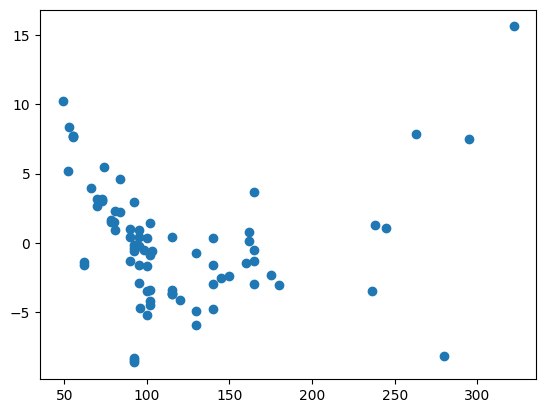

In [56]:
plt.scatter(data=cars_data,x='HP',y = "Error")

In [57]:
del cars_data['Error']
cars_data

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


<Axes: xlabel='HP', ylabel='MPG'>

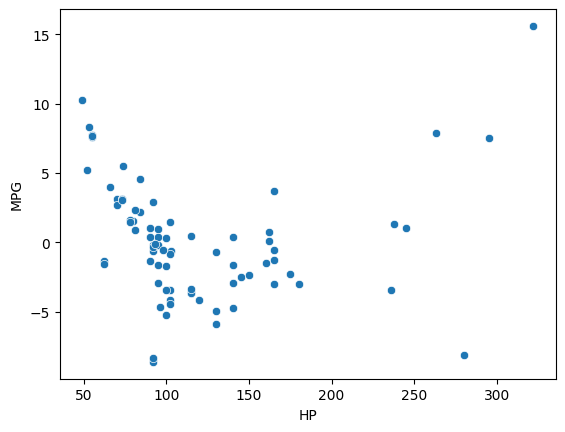

In [58]:
sns.scatterplot(data=cars_data,x="HP",y=error)

<Axes: xlabel='SP', ylabel='MPG'>

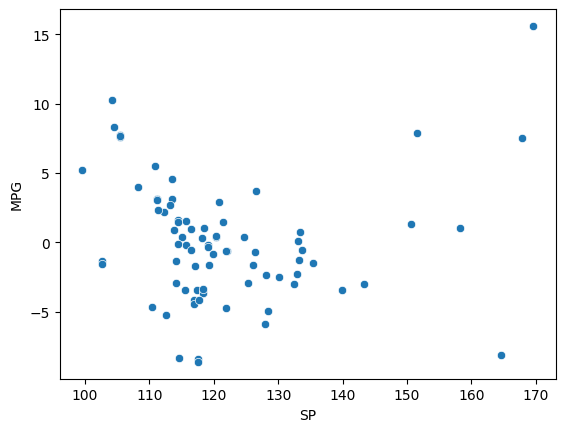

In [59]:
sns.scatterplot(data=cars_data,x="SP",y=error)

<Axes: xlabel='VOL', ylabel='MPG'>

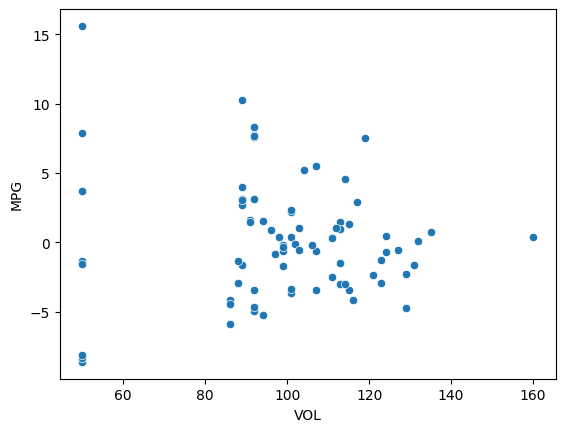

In [60]:
sns.scatterplot(data=cars_data,x="VOL",y=error)

<Axes: xlabel='WT', ylabel='MPG'>

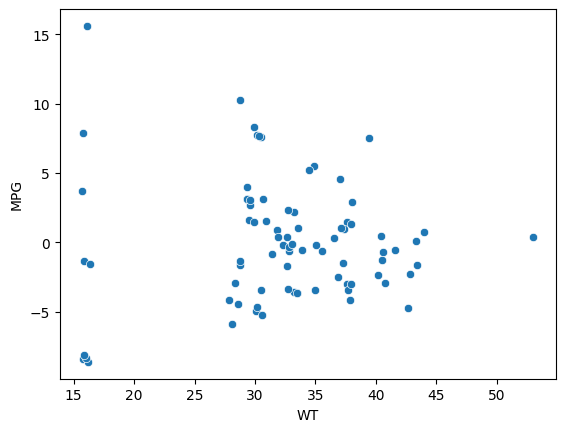

In [61]:
sns.scatterplot(data=cars_data,x="WT",y=error)

#### Test -5 Homoscedasticity test Failed

#### Zero residual Mean test 

<Axes: xlabel='MPG'>

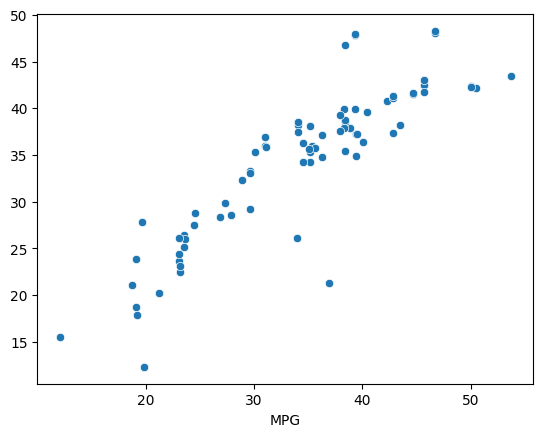

In [62]:
sns.scatterplot(x=y,y=y_pred)

#### test-6 Zero Residual Mean test Failed

### 9. Model deployment

In [63]:
# Linear_model  ---- Intelligence File

from pickle import dump

In [65]:
dump(obj=Linear_model,file=open(file="Linear_Intelligence_file",mode='wb'))

In [66]:
from pickle import load

In [67]:
linear_intel_pkl = load(file = open(file="Linear_Intelligence_file",mode='rb'))

In [69]:
linear_intel_pkl.predict(X)

array([43.44193477, 42.38879289, 42.27934147, 42.53835981, 42.17264802,
       43.02061916, 42.32536062, 48.07621852, 48.28120247, 40.79122814,
       41.52153227, 47.80956747, 39.95980269, 41.52757889, 41.76632332,
       41.6181448 , 41.15094046, 47.98605515, 41.30861046, 37.87127922,
       38.57706414, 37.35199705, 37.89770285, 39.5625144 , 39.93380662,
       46.73870908, 35.48165898, 38.78152504, 38.24861192, 36.00285298,
       34.84603989, 37.21630246, 37.13919796, 34.82541399, 37.22361389,
       37.53950097, 39.27144845, 38.24219888, 38.54286458, 35.9391722 ,
       34.2129755 , 35.36313259, 37.50473376, 38.07998482, 35.79651664,
       36.2613377 , 34.21826465, 35.59393404, 36.91805291, 33.31108154,
       33.21313413, 33.3023649 , 29.19864884, 27.52358579, 28.3207133 ,
       28.56722621, 35.81583602, 33.02108459, 35.37334971, 32.29909503,
       29.87685849, 28.76093817, 25.14188416, 26.47040896, 25.97651933,
       36.35652478, 26.0975912 , 23.6416178 , 24.39887199, 20.21

## THE END!!!

# Evaluation metrices for Regression 

In [41]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score

In [32]:
error.mean()

np.float64(3.50885301609926e-16)

In [34]:
mean_absolute_error(y,y_pred)

3.267968285420799

In [35]:
mean_squared_error(y,y_pred)

18.8971411523431

In [37]:
root_mean_squared_error(y,y_pred)

4.347084212704315

In [39]:
r2_score(y,y_pred)

0.7705372737359844

In [40]:
import statsmodels.formula.api as smf

In [46]:
linear_stats_model = smf.ols(formula="MPG ~ HP+VOL+SP+WT",data=cars_data).fit()

In [47]:
print(
    "R2 Score: ",linear_stats_model.rsquared.round(3),'\nAdjusted R2 Score:',linear_stats_model.rsquared_adj.round(3)
)

R2 Score:  0.771 
Adjusted R2 Score: 0.758


In [48]:
linear_stats_model = smf.ols(formula="MPG ~ HP",data=cars_data).fit()

In [49]:
print(
    "R2 Score: ",linear_stats_model.rsquared.round(3),'\nAdjusted R2 Score:',linear_stats_model.rsquared_adj.round(3)
)

R2 Score:  0.526 
Adjusted R2 Score: 0.52


In [50]:
linear_stats_model = smf.ols(formula="MPG ~ HP+VOL",data=cars_data).fit()

In [51]:
print(
    "R2 Score: ",linear_stats_model.rsquared.round(3),'\nAdjusted R2 Score:',linear_stats_model.rsquared_adj.round(3)
)

R2 Score:  0.751 
Adjusted R2 Score: 0.744


In [52]:
linear_stats_model = smf.ols(formula="MPG ~ HP+VOL+SP",data=cars_data).fit()

In [53]:
print(
    "R2 Score: ",linear_stats_model.rsquared.round(3),'\nAdjusted R2 Score:',linear_stats_model.rsquared_adj.round(3)
)

R2 Score:  0.77 
Adjusted R2 Score: 0.761


In [54]:
linear_stats_model = smf.ols(formula="MPG ~ HP+VOL+SP+WT",data=cars_data).fit()

In [55]:
print(
    "R2 Score: ",linear_stats_model.rsquared.round(3),'\nAdjusted R2 Score:',linear_stats_model.rsquared_adj.round(3)
)

R2 Score:  0.771 
Adjusted R2 Score: 0.758


## SO WE ADJUSTED R2 SCORE, WE ARE USING OLS TECHNIQU